In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import os

from src.constants import EARLY_NTCP_TIMEPOINTS
def determine_CITOR_model_name(endpoint_name):
    endpoint_name = endpoint_name.lower()

    toxicity_name = "_".join(endpoint_name.split("_")[:-1])
    if toxicity_name == 'sticky':
        toxicity_name = 'sticky_saliva'

    timepoint = endpoint_name.split("_")[-1]

    CITOR_name = toxicity_name
    if timepoint in EARLY_NTCP_TIMEPOINTS:
        CITOR_name += "_early"
    else:
        CITOR_name += "_late"

    return CITOR_name



def refit_CITOR_model(config, df_train, endpoint = "Xerostomia_M06", CITOR_model_name = 'xerostomia_late'):
    
    if len(config['CITOR'][CITOR_model_name]['models'].keys()) > 1:
        feature_dict = {'model1':{}, 'model2':{}}
        submodel_names = ['model1', 'model2']

        #all_feature_columns = list(set()) 
    else:
        feature_dict = {'model1':{}}
        submodel_names = ['model1']   


    # refit (all of the sub-) models
    for submodel_names in submodel_names:
        # select the columns per submodel
        feature_column_names = np.array(config['CITOR'][CITOR_model_name]['models'][submodel_names]['features'])

        X_train = df_train[feature_column_names]
        y_train = df_train[endpoint]

        # make and fit the (sub)model
        sub_model = LogisticRegression(random_state=config['general']['seed'], C=1e10, max_iter = 1000)

        # Messy things to handle any missing data
        valid_indices = y_train != -1
        X_train = X_train[valid_indices]
        y_train = y_train[valid_indices]
        
        # fit the model
        sub_model.fit(X_train, y_train)

        # save the submodel in the feature_dict
        feature_dict[submodel_names]['features'] = feature_column_names
        feature_dict[submodel_names]['coef'] = sub_model.coef_[0]
        feature_dict[submodel_names]['intercept'] = sub_model.intercept_[0]

        # print(f"submodel {submodel_names} has been fitted")
        # sub_model_dict = {f: c for f, c in zip(feature_column_names, sub_model.coef_[0])}
        # print(sub_model_dict)
        # print(feature_dict[submodel_names]['intercept'])


    # combine the submodels
    if len(feature_dict.keys()) > 1:
        model1 = list(feature_dict.keys())[0]
        model2 = list(feature_dict.keys())[1]
        features = []
        coef = []
        features.append('intercept')
        coef.append(.5*(feature_dict[model1]['intercept'] + feature_dict[model2]['intercept']))
        
        features1 = feature_dict[model1]['features']
        features2 = feature_dict[model2]['features']
        
        overlap =  list(set(features1) & set(features2))
        remainder_m1 = list(set(features1) - set(features2))
        remainder_m2 = list(set(features2) - set(features1))

        
        for i in range(len(remainder_m1)):
            features.append(remainder_m1[i])
            coef.append(.5*(feature_dict[model1]['coef'][np.where(features1 == remainder_m1[i])])[0])         
        for i in range(len(remainder_m2)):
            features.append(remainder_m2[i])
            coef.append(.5*(feature_dict[model2]['coef'][np.where(features2 == remainder_m2[i])])[0])    
        for i in range(len(overlap)):
            features.append(overlap[i])
            coef.append(.5*(feature_dict[model1]['coef'][np.where(features1 == overlap[i])]+feature_dict[model2]['coef'][np.where(features2 == overlap[i])])[0])     
   
    else:
        features = ['intercept'] + list(feature_column_names)
        coef =[sub_model.intercept_[0]] + list(sub_model.coef_[0]) 


    # print(features)
    # features_coeff_dict = {k: v for k, v in zip(features, coef)}
    # print(features_coeff_dict)
    # print(coef[1:])
    
    model = LogisticRegression(random_state=config['general']['seed'], C=1e10, max_iter = 1000, multi_class='ovr')
    model.intercept_ = np.array([coef[0]])
    model.coef_ = np.array([coef[1:]])

    return model, features[1:] 


PATIENT_ID_COL_NAME = "PatientID"

def run_logistic_regression_posthoc(config, df_features, train_val_patient_IDs, test_patient_IDs, endpoint_list = ["Xerostomia_M06"]):
    # get the train and val patients' data
    df_train_val = df_features[df_features[PATIENT_ID_COL_NAME].isin(train_val_patient_IDs)]

    # get the test patients' data (if you want that)
    df_test = df_features[df_features[PATIENT_ID_COL_NAME].isin(test_patient_IDs)]

    test_aucs_dict = {}
    

    for idx, endpoint in enumerate(endpoint_list):
        #print(f"fitting models for {endpoint}")
        CITOR_model_name = determine_CITOR_model_name(endpoint)
        #print(CITOR_model_name)

        model, feature_column_names = refit_CITOR_model(config, df_train_val, endpoint = endpoint, CITOR_model_name = CITOR_model_name)

        df_train_val_X = df_train_val.loc[:, feature_column_names].values

        train_val_preds = model.predict_proba(df_train_val_X)[:,1]

        df_test_X = df_test.loc[:, feature_column_names].values
        test_preds = model.predict_proba(df_test_X)[:,1]


        # compute the AUC
        #print(test_preds)
        #print(len(df_test_X), len(test_preds), len(df_test[endpoint]))

        indicies = np.where(df_test[endpoint] != -1)[0]

        y_pred = test_preds[indicies]
        y_true = df_test[endpoint].values[indicies]
        #print(y_pred)

        auc = roc_auc_score(y_true, y_pred)

        test_aucs_dict[endpoint] = round(auc, 23)

    return test_aucs_dict


ModuleNotFoundError: No module named 'pandas._libs.pandas_parser'

In [ ]:
pip uninstall pandas

In [ ]:
pip install pandas

In [ ]:
from src.config_presets.tools.get_config import get_config
config = get_config('Trial32_Config')

src\config_presets\Base_config.yaml
src\config_presets\Trial32_Config.yaml


In [ ]:
from tqdm import tqdm


splits_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\PRI2MA\HNC_complete_dataset_excel\Draft datasets\test_split_seeds"

split_files = os.listdir(splits_dir)

endpoint_list = ["Aspiration_M06", "Dysphagia_M06", "Sticky_M06", "Taste_M06", "Xerostomia_M06"]
#split_files.sort()

all_test_aucs_dict = []

#for rand_seed in tqdm(range(1000)):
for rand_seed in tqdm([34]):
    #print(filename)
    rand_seed = str(rand_seed).zfill(3)
    df = pd.read_csv(os.path.join(splits_dir, f"train_val_test_split_{rand_seed}.csv"))

    df_train_val = df[df['Split'] == 'train_val']
    df_test = df[df['Split'] == 'test']
    train_val_patient_IDs = df_train_val['PatientID'].values
    test_patient_IDs = df_test['PatientID'].values

    test_aucs_dict = run_logistic_regression_posthoc(config, df, train_val_patient_IDs, test_patient_IDs, endpoint_list = endpoint_list)
    test_aucs_dict['seed'] = rand_seed  # int(filename.split('.')[0].split('_')[-1])
    all_test_aucs_dict.append(test_aucs_dict)

  0%|          | 0/1 [00:00<?, ?it/s]


KeyError: 'aspiration_late'

In [23]:
df_test_aucs = pd.DataFrame(all_test_aucs_dict)
df_test_aucs.set_index('seed', inplace=True)

In [25]:
# Assuming df_test_aucs is your DataFrame
column_means = df_test_aucs.mean(axis=0)

# Print the means
print(column_means)

Aspiration_M06    0.731328
Dysphagia_M06     0.820056
Sticky_M06        0.711731
Taste_M06         0.714915
Xerostomia_M06    0.736019
dtype: float64


In [26]:
# Calculate the mean of each column
column_means = df_test_aucs.mean(axis=0)

# Calculate the mean distance for each row across all columns
df_test_aucs['mean_distance'] = df_test_aucs.apply(lambda row: abs((row - column_means)).sum(), axis=1)

# Sort the rows by the mean distance and select the top 10 rows
top_10_nearest = df_test_aucs.nsmallest(10, 'mean_distance')

# Drop the temporary 'mean_distance' column if no longer needed
df_test_aucs.drop(columns=['mean_distance'], inplace=True)

# Print the top 10 rows
print(top_10_nearest)

      Aspiration_M06  Dysphagia_M06  Sticky_M06  Taste_M06  Xerostomia_M06  \
seed                                                                         
034         0.731328       0.820056    0.711731   0.714915        0.736019   

      mean_distance  
seed                 
034             0.0  


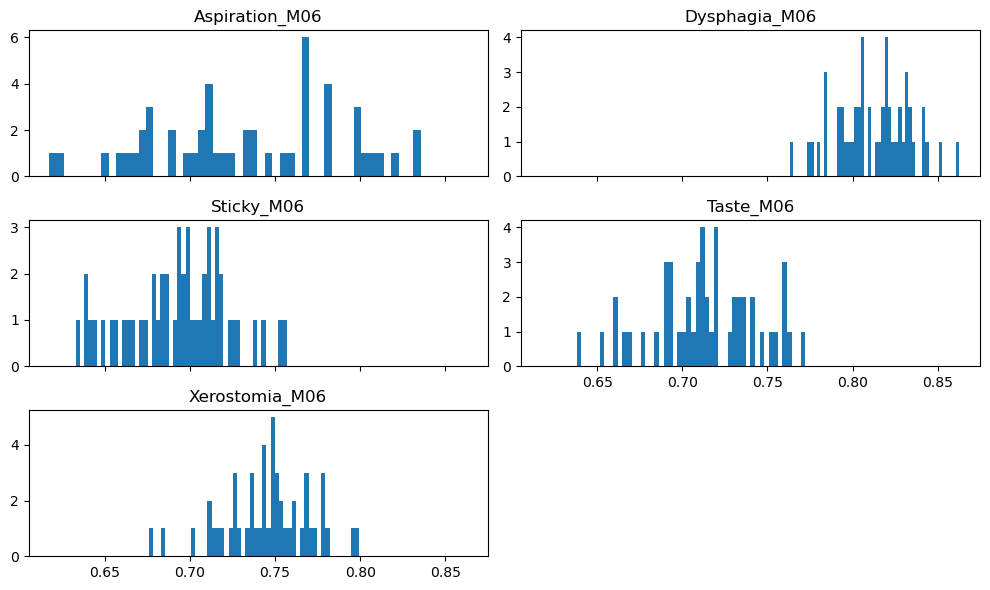

In [11]:
# Plot histograms for all columns
df_test_aucs.hist(figsize=(10, 6), grid=False, bins=50, sharex=True)

import matplotlib.pyplot as plt
# Show the plot
plt.tight_layout()
plt.show()